# Metrics & Preprocessing Review Notebook — aligned with current pipeline

This notebook helps you **inspect the project outputs** without retraining everything.

It is aligned with the current pipeline where:
- **subjects** are loaded from the available artifact (`subject_predictions_sbert.csv` first, fallback only if needed),
- the **sentiment model** is a TF-IDF + SGDClassifier,
- the **star model** is a **hybrid regressor**: Sentence-BERT + optional Word2Vec + TF-IDF + TruncatedSVD + metadata + XGBoost Regressor,
- the exported star metrics therefore contain **both regression metrics** (`r2_train`, `r2_test`, `rmse_test`) and **rounded classification metrics** (`accuracy`, `weighted_f1`, `macro_f1`).

The goal is to keep the notebook paths unchanged while making the interpretation consistent with `src/pipeline.py`.


In [ ]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)

# Optional: set this manually if your notebook is not launched from the project root.
# Example:
# PROJECT_DIR = Path("/home/your_name/path/to/reworked_nlp_reviews_project")
PROJECT_DIR = Path.cwd()

ART_DIR = PROJECT_DIR / "artifacts"
REP_DIR = PROJECT_DIR / "reports"
DATA_DIR = PROJECT_DIR / "data"

print("PROJECT_DIR =", PROJECT_DIR)
print("ART_DIR exists :", ART_DIR.exists())
print("REP_DIR exists :", REP_DIR.exists())
print("DATA_DIR exists:", DATA_DIR.exists())


PROJECT_DIR = /home/noker-505/Téléchargements/reworked_nlp_reviews_project
ART_DIR exists : True
REP_DIR exists : True
DATA_DIR exists: True


## 1. Helper functions

In [ ]:
def safe_read_csv(path):
    if path.exists():
        return pd.read_csv(path)
    print(f"Missing CSV: {path}")
    return None

def safe_read_json(path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    print(f"Missing JSON: {path}")
    return None

def show_df(title, df, n=10):
    print(f"\n=== {title} ===")
    if df is None:
        print("Not available")
    else:
        display(df.head(n))

def classification_report_to_df(report_dict):
    if report_dict is None:
        return None
    return pd.DataFrame(report_dict).transpose()

def safe_read_text(path):
    if path.exists():
        return path.read_text(encoding="utf-8")
    print(f"Missing text file: {path}")
    return None

## 2. Load generated project files

In [ ]:
reviews_processed = safe_read_csv(DATA_DIR / "reviews_processed.csv")

dataset_summary = safe_read_json(REP_DIR / "dataset_summary.json")
topics_nmf = safe_read_csv(REP_DIR / "topics_nmf.csv")
top_unigrams = safe_read_csv(REP_DIR / "top_unigrams.csv")
top_bigrams = safe_read_csv(REP_DIR / "top_bigrams.csv")
ngrams_by_sentiment = safe_read_csv(REP_DIR / "ngrams_by_sentiment.csv")
avg_rating_by_insurer = safe_read_csv(REP_DIR / "avg_rating_by_insurer.csv")
avg_rating_by_product = safe_read_csv(REP_DIR / "avg_rating_by_product.csv")

dataset_driven_choices = safe_read_text(REP_DIR / "dataset_driven_choices.md")

star_model_comparison = safe_read_csv(ART_DIR / "star_rating_model_comparison.csv")
star_report_json = safe_read_json(ART_DIR / "star_rating_classification_report.json")
star_conf_matrix = safe_read_csv(ART_DIR / "star_rating_confusion_matrix.csv")
star_errors = safe_read_csv(ART_DIR / "star_rating_error_examples.csv")
star_best_model = safe_read_text(ART_DIR / "star_rating_best_model.txt")
star_best_params = safe_read_json(ART_DIR / "star_rating_best_params.json")

sent_model_comparison = safe_read_csv(ART_DIR / "sentiment_model_comparison.csv")
sent_report_json = safe_read_json(ART_DIR / "sentiment_classification_report.json")
sent_conf_matrix = safe_read_csv(ART_DIR / "sentiment_confusion_matrix.csv")
sent_errors = safe_read_csv(ART_DIR / "sentiment_error_examples.csv")
sent_best_model = safe_read_text(ART_DIR / "sentiment_best_model.txt")

test_predictions = safe_read_csv(ART_DIR / "test_predictions.csv")
search_metadata = safe_read_csv(ART_DIR / "search_metadata.csv")

# Current pipeline: prefer SBERT subject outputs.
# Fallback to zero-shot only if the SBERT file is not present.
subject_labels_used = safe_read_json(ART_DIR / "subject_labels_used.json")
subject_predictions_sbert = safe_read_csv(ART_DIR / "subject_predictions_sbert.csv")
subject_predictions_zero_shot = safe_read_csv(ART_DIR / "subject_predictions_zero_shot.csv")

if subject_predictions_sbert is not None:
    subject_predictions = subject_predictions_sbert
    subject_predictions_name = "SBERT"
elif subject_predictions_zero_shot is not None:
    subject_predictions = subject_predictions_zero_shot
    subject_predictions_name = "zero-shot"
else:
    subject_predictions = None
    subject_predictions_name = None


/tmp/ipykernel_903656/4098061431.py:3: DtypeWarning: Columns (9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


Missing CSV: /home/noker-505/Téléchargements/reworked_nlp_reviews_project/artifacts/subject_predictions_zero_shot.csv


In [ ]:
print("Loaded subject artifact:", subject_predictions_name)

if star_model_comparison is not None and not star_model_comparison.empty:
    star_cols = list(star_model_comparison.columns)
    print("Star model comparison columns:", star_cols)
    print("Notebook interpretation: regression model + rounded-star evaluation")


Loaded subject artifact: SBERT
Star model comparison columns: ['task', 'model', 'r2_train', 'r2_test', 'rmse_test', 'accuracy', 'weighted_f1', 'macro_f1']
Notebook interpretation: regression model + rounded-star evaluation


## 3. Preprocessing choices used in the project

In [ ]:
print(dataset_driven_choices if dataset_driven_choices is not None else "No preprocessing note found.")

# Dataset-driven choices

- The uploaded zip contains multiple Excel files merged into one dataset.
- The useful split already exists in the `type` column: `train` rows have labels and `test` rows have missing `note` values.
- The original French review is stored in `avis` and the English translation in `avis_en`.
- Human-corrected text exists only for a small subset, so the pipeline uses corrected text when available and otherwise falls back to the original text.
- Subject detection is handled with multilingual Sentence-BERT and exported as `subject_predictions_sbert.csv`.
- The final star model is a single aligned hybrid model:
  Sentence-BERT embeddings + Word2Vec + TF-IDF + TruncatedSVD + metadata + XGBoost Regressor.
- TF-IDF/SVD hyperparameters and XGBoost hyperparameters are searched jointly.
- The sentiment model remains TF-IDF + SGDClassifier for speed and notebook compatibility.



<div style="margin-top: 24px; margin-bottom: 18px;">

### Commentaire rapide sur les choix de preprocessing

Ce qu'on voit déjà dans les fichiers chargés, c'est que le dataset est assez hétérogène : plusieurs fichiers Excel au départ, des langues différentes, quelques corrections humaines mais pas tant que ça, et un mélange de colonnes brutes et de colonnes déjà retravaillées.  
Du coup, le preprocessing choisi par la pipeline se comprend plutôt bien.

- Le fait de **garder le texte corrigé quand il existe**, mais de **retomber sur le texte original sinon**, c'est logique, parce qu'il n'y a que **435 lignes corrigées** sur **34434**. Donc si on exigeait la correction humaine partout, on perdrait presque tout.
- Le fait de construire une colonne finale de travail comme `review_clean_model`, ça évite aussi d'avoir un pipeline qui change tout le temps entre `avis`, `avis_cor`, `review_best_fr`, etc. C'est plus stable, même si dit comme ça ça a l'air un peu basique.
- Le split **train / test** déjà présent dans la colonne `type` justifie aussi qu'on ne réinvente pas un split maison. En gros, on suit la structure du dataset au lieu de forcer un découpage artificiel.
- Enfin, le choix d'un sujet final stocké dans `subject_rule` mais adossé au passage SBERT se tient, parce que ça donne une sortie exploitable, plus simple à relire dans les fichiers exportés.

Ce qui est important à retenir, c'est que les choix n'ont pas été faits "pour faire joli", mais surtout parce que la forme du dataset obligeait un peu à aller vers quelque chose de robuste et praticable.

</div>


In [ ]:
if reviews_processed is not None:
    print("Rows, columns:", reviews_processed.shape)
    print("\nColumns:")
    print(list(reviews_processed.columns))

    useful_cols = [c for c in [
        "review_id", "note", "avis", "avis_cor", "avis_en", "avis_cor_en",
        "review_best_fr", "review_best_en", "review_clean_fr", "review_clean_en",
        "review_clean_model", "sentiment_label", "subject_rule", "type",
        "text_len_chars", "text_len_words"
    ] if c in reviews_processed.columns]

    display(reviews_processed[useful_cols].head(5))
else:
    print("reviews_processed.csv not found.")

Rows, columns: (34434, 30)

Columns:
['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en', 'source_file', 'review_id', 'review_best_fr', 'review_best_en', 'has_human_correction', 'review_clean_fr', 'review_clean_en', 'review_clean_model', 'text_len_chars', 'text_len_words', 'year_publication', 'month_publication', 'sentiment_label', 'is_train', 'is_test', 'subject_sbert', 'subject_sbert_score', 'subject_rule', 'subject_keywords']


,review_id,note,avis,avis_cor,avis_en,avis_cor_en,review_best_fr,review_best_en,review_clean_fr,review_clean_en,review_clean_model,sentiment_label,subject_rule,type,text_len_chars,text_len_words
0,R000001,4.0,La personne au téléphone était Clair et sympat...,NaN,The person on the phone was clear and friendly...,NaN,La personne au téléphone était Clair et sympat...,The person on the phone was clear and friendly...,la personne au téléphone était clair et sympat...,the person on the phone was clear and friendly...,la personne au téléphone était clair et sympat...,positive,Customer Service,train,166,26
1,R000002,4.0,"Satisfait.\n\nRéactivité, simplicité. Prix att...",NaN,"Satisfied.\n\nReactivity, simplicity. Attracti...",NaN,"Satisfait.\n\nRéactivité, simplicité. Prix att...","Satisfied.\n\nReactivity, simplicity. Attracti...",satisfait réactivité simplicité prix attractif...,satisfied reactivity simplicity attractive pri...,satisfait réactivité simplicité prix attractif...,positive,Pricing,train,153,22
2,R000003,1.0,"Assureur à fuir, n assure pas ses responsabili...",NaN,"Insurer to flee, does not ensure its responsib...",NaN,"Assureur à fuir, n assure pas ses responsabili...","Insurer to flee, does not ensure its responsib...",assureur à fuir n assure pas ses responsabilit...,insurer to flee does not ensure its responsibi...,assureur à fuir n assure pas ses responsabilit...,negative,Claims Processing,train,200,35
3,R000004,1.0,Voilà 3 mois que la GMF me fait attendre pour ...,NaN,The GMF has been waiting for a water damage fo...,NaN,Voilà 3 mois que la GMF me fait attendre pour ...,The GMF has been waiting for a water damage fo...,voilà 3 mois que la gmf me fait attendre pour ...,the gmf has been waiting for a water damage fo...,voilà 3 mois que la gmf me fait attendre pour ...,negative,Claims Processing,train,121,23
4,R000005,3.0,Je suis bien avec cet assurance.elle est prati...,NaN,I am good with this insurance. She is practica...,NaN,Je suis bien avec cet assurance.elle est prati...,I am good with this insurance. She is practica...,je suis bien avec cet assurance elle est prati...,i am good with this insurance she is practical...,je suis bien avec cet assurance elle est prati...,neutral,Coverage,train,170,31


### Short explanation of preprocessing logic

Typical project logic:
- merge all Excel files,
- remove duplicates,
- keep the original French review,
- use corrected text if available,
- clean text (`clean_text`),
- create a final modeling text column (`review_clean_model`),
- derive `sentiment_label` from `note`,
- assign subjects with the current SBERT-based subject step,
- export analysis tables and trained artifacts.

Important alignment note:
- the final **star** pipeline is **not** a pure classifier anymore,
- it is a **regression model** whose continuous output is rounded back to 1–5 stars for evaluation and export.


## 4. Dataset overview

In [ ]:
print("Dataset summary JSON:")
display(pd.DataFrame([dataset_summary]) if dataset_summary is not None else pd.DataFrame())

Dataset summary JSON:


,rows_total,rows_train,rows_test,n_unique_insurers,n_unique_products,n_human_corrected_rows,missing_note_total,train_note_distribution,sentiment_distribution,top_products,top_insurers
0,34434,24104,10330,56,13,435,10330,"{'1.0': 7271, '2.0': 3716, '3.0': 3382, '4.0':...","{'negative': 10987, 'positive': 9735, 'neutral...","{'auto': 14076, 'sante': 3525, 'moto': 2105, '...","{'Direct Assurance': 5896, 'L'olivier Assuranc..."


In [ ]:
show_df("Topics (NMF)", topics_nmf)
show_df("Top unigrams", top_unigrams, n=20)
show_df("Top bigrams", top_bigrams, n=20)
show_df("Average rating by insurer", avg_rating_by_insurer, n=20)
show_df("Average rating by product", avg_rating_by_product, n=20)


=== Topics (NMF) ===


,topic,top_terms
0,Topic 1,"service, satisfait, client, cordialement, rapi..."
1,Topic 2,"mois, contrat, sinistre, faire, ans, dossier, ..."
2,Topic 3,"assurance, direct, olivier, recommande, auto, ..."
3,Topic 4,"rapide, simple, efficace, pratique, site, faci..."
4,Topic 5,"satisfaite, écoute, tres, bon, bonne, accueil,..."
5,Topic 6,"prix, rapport, qualité, voir, bon, correct, ga..."



=== Top unigrams ===


,ngram,count
0,assurance,12386
1,service,6646
2,prix,6416
3,contrat,5133
4,mois,4590
5,satisfait,4130
6,faire,3844
7,sinistre,3579
8,client,3402
9,ans,3294



=== Top bigrams ===


,ngram,count
0,service client,1553
1,direct assurance,1360
2,satisfait service,1287
3,prise charge,1018
4,olivier assurance,562
5,satisfaite service,480
6,qualité prix,477
7,assurance auto,458
8,service prix,456
9,satisfait prix,420



=== Average rating by insurer ===


,assureur,count,mean
0,Zen'Up,245,4.436735
1,APRIL Moto,1023,3.946237
2,L'olivier Assurance,4288,3.829757
3,AMV,688,3.691860
4,MGP,446,3.589686
5,Santiane,658,3.468085
6,Direct Assurance,5896,3.314790
7,GMF,997,2.886660
8,Néoliane Santé,861,2.795587
9,Génération,212,2.750000



=== Average rating by product ===


,produit,count,mean
0,auto,14076,3.145425
1,sante,3525,2.531348
2,moto,2105,3.501188
3,habitation,1956,1.738753
4,prevoyance,791,1.661188
5,credit,653,2.647779
6,vie,578,1.477509
7,animaux,374,1.820856
8,multirisque-professionnelle,20,2.850000
9,garantie-decennale,12,1.583333


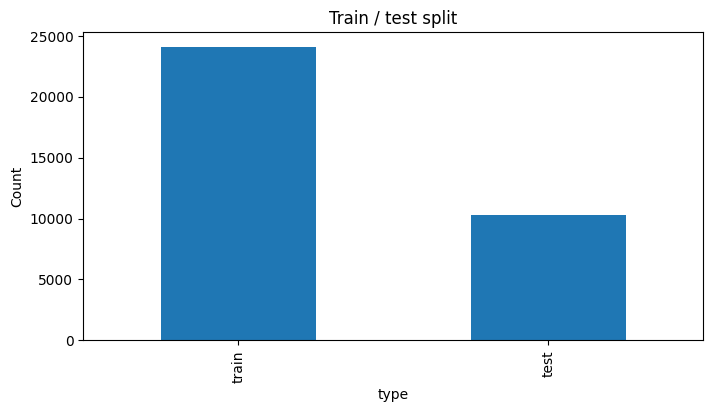

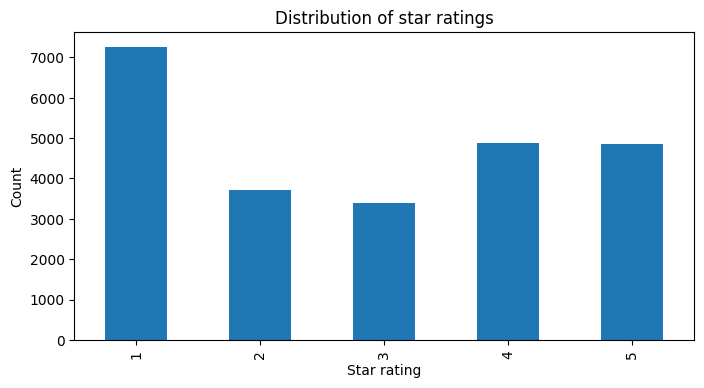

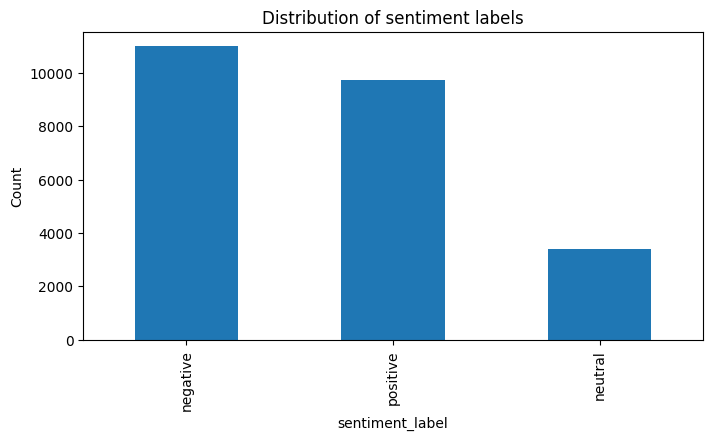

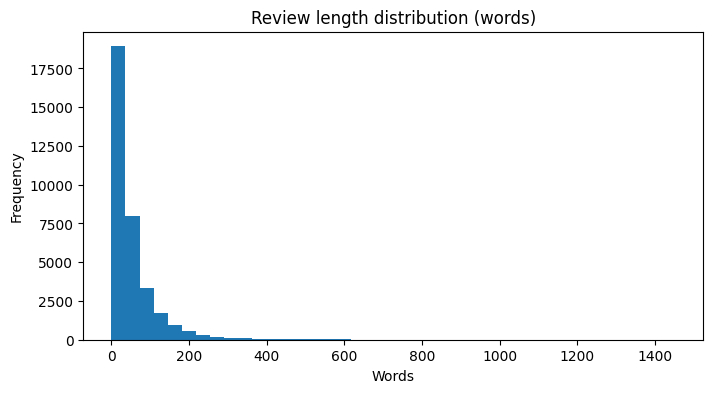

In [ ]:
if reviews_processed is not None:
    fig, ax = plt.subplots()
    reviews_processed["type"].value_counts(dropna=False).plot(kind="bar", ax=ax)
    ax.set_title("Train / test split")
    ax.set_ylabel("Count")
    plt.show()

    if "note" in reviews_processed.columns:
        fig, ax = plt.subplots()
        reviews_processed["note"].dropna().astype(int).value_counts().sort_index().plot(kind="bar", ax=ax)
        ax.set_title("Distribution of star ratings")
        ax.set_xlabel("Star rating")
        ax.set_ylabel("Count")
        plt.show()

    if "sentiment_label" in reviews_processed.columns:
        fig, ax = plt.subplots()
        reviews_processed["sentiment_label"].dropna().value_counts().plot(kind="bar", ax=ax)
        ax.set_title("Distribution of sentiment labels")
        ax.set_ylabel("Count")
        plt.show()

    if "text_len_words" in reviews_processed.columns:
        fig, ax = plt.subplots()
        reviews_processed["text_len_words"].dropna().plot(kind="hist", bins=40, ax=ax)
        ax.set_title("Review length distribution (words)")
        ax.set_xlabel("Words")
        plt.show()

<div style="margin-top: 28px; margin-bottom: 22px;">

## Interprétation de l'EDA et des graphes de distribution

À partir des graphes affichés juste au-dessus, on peut tirer plusieurs trucs assez utiles pour comprendre les décisions du projet.

### 1) Répartition train / test

Le graphe de split montre un dataset avec :
- **24104 lignes train**
- **10330 lignes test**

Donc on a quand même une base d'entraînement assez grande. Ça explique qu'on puisse se permettre :
- un modèle de sentiment assez classique en TF-IDF + SGD,
- une partie étoile plus ambitieuse, avec embeddings + réduction de dimension + XGBoost,
- et une EDA qui a du sens, parce qu'on ne travaille pas sur quelques centaines de lignes seulement.

### 2) Distribution des notes

Le graphe des notes montre que la distribution n'est pas homogène.  
On voit clairement que certaines notes sont plus présentes que d'autres, avec notamment beaucoup de **1 étoiles** et aussi pas mal de **4 / 5**.  
Donc le problème n'est pas du tout un cas bien équilibré, bien propre.

Ça justifie plusieurs choix :
- pour le **sentiment**, la transformation des notes en labels `negative / neutral / positive` simplifie un peu le problème ;
- pour les **étoiles**, utiliser un **modèle de régression** est assez malin, parce que les notes ont un ordre naturel, et forcer une classification brute 1-2-3-4-5 aurait été un peu raide ;
- le fait de regarder aussi les erreurs après **arrondi** est important, parce qu'un 4 prédit au lieu d'un 5 est moins grave qu'un 1 prédit pour un 5.

### 3) Distribution du sentiment

Le graphe sentiment montre une masse importante de `negative` et `positive`, alors que `neutral` paraît moins naturel dans le dataset.  
Et ça, en vrai, on le retrouve plus tard dans les métriques du modèle : le neutre est celui qui souffre le plus.

Du coup, ce graphe annonce déjà un peu le problème :
- les avis franchement positifs ou franchement négatifs ont des marqueurs lexicaux assez visibles ;
- les avis neutres sont souvent des cas mélangés, ambigus, ou simplement moins bien séparés.

### 4) Longueur des reviews

L'histogramme de `text_len_words` montre une dispersion assez large.  
Il y a des avis courts, d'autres beaucoup plus longs. Ce n'est pas juste du mini commentaire standardisé.

Ça aide à comprendre pourquoi la pipeline garde aussi des **features metadata**, notamment :
- `text_len_words`
- `year_publication`
- `has_human_correction`

Même si ces variables ne portent pas tout le signal, elles peuvent ajouter un petit contexte utile. Et surtout, sur des reviews très courtes, le texte seul peut parfois être trop pauvre.

### 5) Topics NMF et n-grams

Les topics NMF, les top unigrams et les top bigrams racontent une chose assez nette : le corpus tourne beaucoup autour de thèmes comme :
- le **service**
- le **prix**
- le **contrat**
- les **sinistres**
- la **rapidité**
- la **prise en charge**

Autrement dit, le dataset est bien centré métier, pas juste du texte généraliste.  
Ça soutient plusieurs choix :
- l'utilisation d'un **TF-IDF** reste pertinente, parce que beaucoup de termes métier reviennent de façon structurée ;
- la détection de **sujets** comme `Pricing`, `Customer Service`, `Claims Processing` n'est pas sortie de nulle part, elle colle à ce qu'on voit dans les mots les plus fréquents ;
- les embeddings type SBERT sont utiles pour aller plus loin que la simple fréquence, surtout quand deux avis parlent de la même chose avec des formulations différentes.

### 6) Répartition par assureur et produit

Les tableaux `avg_rating_by_insurer` et `avg_rating_by_product` montrent que le dataset n'est pas neutre du tout selon les entités.  
Certaines marques et certains produits ont des moyennes beaucoup plus hautes ou plus basses.

Ça justifie le fait d'avoir gardé les colonnes :
- `assureur`
- `produit`

et d'en faire des **features metadata** dans le pipeline étoiles.  
Ce n'est pas juste décoratif : la note dépend aussi du contexte produit / assureur, pas seulement des mots utilisés dans l'avis.

### Conclusion EDA

Donc, si on résume de façon simple :
- le dataset est **assez gros** pour tenter des modèles solides,
- il est **déséquilibré** sur plusieurs axes,
- les thèmes métier sont **très visibles**,
- le neutre paraît plus flou que les autres classes,
- et le contexte assureur / produit a visiblement un rôle.

Franchement, l'EDA ne sert pas juste à faire des graphes. Ici elle explique vraiment pourquoi la pipeline n'est pas un modèle texte tout nu, mais un empilement plus riche avec texte + structure + contexte.

</div>


## 5. Star prediction metrics

This section reads the exported outputs of the **current star prediction pipeline**.

### Important note on the current star model
The current star model is a **regressor** (`XGBRegressor`) inside a hybrid feature stack:
- Sentence-BERT embeddings,
- optional Word2Vec embeddings,
- TF-IDF + TruncatedSVD features,
- metadata features.

Because of that, the pipeline exports **two families of metrics**:

**Regression metrics**
- `r2_train`
- `r2_test`
- `rmse_test`

**Rounded star metrics**
- `accuracy`
- `weighted_f1`
- `macro_f1`

The classification report and confusion matrix are computed **after rounding/clipping predictions back to 1–5 stars**.


In [ ]:
print("Best star model:")
print(star_best_model if star_best_model is not None else "Not available")

print("\nBest star-model parameters / bundle settings:")
display(pd.DataFrame([star_best_params]) if star_best_params is not None else pd.DataFrame())

show_df("Star model comparison", star_model_comparison)

if star_model_comparison is not None and not star_model_comparison.empty:
    metric_cols = [c for c in ["r2_train", "r2_test", "rmse_test", "accuracy", "weighted_f1", "macro_f1"] if c in star_model_comparison.columns]
    print("\nKey exported metrics:")
    display(star_model_comparison[metric_cols])

star_report_df = classification_report_to_df(star_report_json)
show_df("Star classification report (rounded predictions)", star_report_df, n=20)

show_df("Star confusion matrix (rounded predictions)", star_conf_matrix, n=20)
show_df("Star error examples", star_errors, n=20)


Best star model:
hybrid_sbert_w2v_tfidf_svd_xgbreg

Best star-model parameters / bundle settings:


,sbert_model_name,tfidf_svd,imbalance,xgb,uses_word2vec,word2vec_dim
0,sentence-transformers/paraphrase-multilingual-...,"{'max_features': 20000, 'ngram_range': [1, 1],...",{'sampler': 'none'},"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",False,0



=== Star model comparison ===


,task,model,r2_train,r2_test,rmse_test,accuracy,weighted_f1,macro_f1
0,star_rating,hybrid_sbert_w2v_tfidf_svd_xgbreg,0.885333,0.704871,0.831961,0.454772,0.453681,0.429207



Key exported metrics:


...

,precision,recall,f1-score,support
1,0.689585,0.469051,0.558330,1454.000000
2,0.313183,0.578735,0.406427,743.000000
3,0.311340,0.223373,0.260121,676.000000
4,0.425776,0.645855,0.513217,977.000000
5,0.606925,0.307216,0.407940,970.000000
accuracy,0.454772,0.454772,0.454772,0.454772
macro avg,0.469362,0.444846,0.429207,4820.000000
weighted avg,0.508406,0.454772,0.453681,4820.000000



=== Star confusion matrix (rounded predictions) ===


,Unnamed: 0,pred_1,pred_2,pred_3,pred_4,pred_5
0,true_1,682,704,56,8,4
1,true_2,217,430,67,26,3
2,true_3,87,175,151,236,27
3,true_4,1,46,140,631,159
4,true_5,2,18,71,581,298



=== Star error examples ===


,text,true_label,pred_label
0,après une mauvaise expérience en passant par l...,5,4
1,bonjour je me bat aujourd hui depuis 2 mois et...,3,1
2,je veux attirer l'attention des clients gmf ap...,3,2
3,contrat signé avec une femme de 102 ans en sig...,1,2
4,on n'est jamais satisfait des pris on aimerai ...,3,4
5,délai supérieur à 3 semaines 10 à 15 jours ann...,1,2
6,j'ai malheureusement eu à faire appel à plusie...,5,4
7,je suis chez axa valenciennes agence sulli dep...,5,4
8,indemnités prévoyance versées très tardivement...,1,2
9,je suis satisfait merci l'olivier niveau inscr...,5,4


In [ ]:
if star_model_comparison is not None and not star_model_comparison.empty:
    metric_cols = [c for c in ["r2_train", "r2_test", "rmse_test", "accuracy", "weighted_f1", "macro_f1"] if c in star_model_comparison.columns]
    display(star_model_comparison[metric_cols])

if star_conf_matrix is not None:
    cm = star_conf_matrix.copy()
    if len(cm.columns) and str(cm.columns[0]).startswith("Unnamed"):
        cm = cm.set_index(cm.columns[0])
    display(cm.style.background_gradient(cmap="Blues"))


,r2_train,r2_test,rmse_test,accuracy,weighted_f1,macro_f1
0,0.885333,0.704871,0.831961,0.454772,0.453681,0.429207


,pred_1,pred_2,pred_3,pred_4,pred_5
Unnamed: 0,,,,,
true_1,682,704,56,8,4
true_2,217,430,67,26,3
true_3,87,175,151,236,27
true_4,1,46,140,631,159
true_5,2,18,71,581,298


<div style="margin-top: 28px; margin-bottom: 22px;">

## Lecture et commentaire des résultats du modèle étoiles

Les résultats montrent un truc assez intéressant, et même un peu typique quand on prédit une note ordonnée.

### 1) Ce que disent les métriques de régression

On lit :
- `r2_train = 0.8853`
- `r2_test = 0.7049`
- `rmse_test = 0.8320`

Déjà, le `R² test` autour de **0.70** est franchement correct.  
Ça veut dire que, dans sa version continue, le modèle capture quand même une partie importante de la variabilité des notes.

Le `R² train` plus haut que le `R² test` est normal. Il y a un écart, donc on sent qu'il y a un peu de sur-apprentissage, mais pas dans des proportions absurdes non plus. On n'est pas sur un effondrement complet hors entraînement.

Le `RMSE` autour de **0.83** veut dire, dit simplement, que l'erreur moyenne est inférieure à une étoile.  
Et pour un problème de notation subjective, ce n'est pas ridicule du tout.

### 2) Pourquoi les métriques après arrondi sont plus basses

Après arrondi/clipping, on tombe sur :
- `accuracy = 0.4548`
- `weighted_f1 = 0.4537`
- `macro_f1 = 0.4292`

Au premier regard, ça peut paraître faible. Mais il faut faire attention :  
le modèle est d'abord un **régressseur**, pas un classifieur pur. Quand on force sa sortie à rentrer dans des cases discrètes 1–5, on perd de l'information.

Par exemple :
- si la vraie note est 5 et que le modèle sort 4.49, après arrondi ça devient 4 ;
- si la vraie note est 1 et que le modèle sort 1.51, après arrondi ça devient 2.

Donc le modèle peut être **pas loin** au sens continu, mais être compté comme faux dans la version discrète.

### 3) Ce que montre la matrice de confusion

La matrice de confusion fait ressortir une tendance très claire :
- beaucoup de `true_1` partent en `pred_2`
- beaucoup de `true_5` partent en `pred_4`
- les notes centrales attirent pas mal de prédictions

Autrement dit, le modèle **lisse**.  
Il a une sorte de prudence statistique, si on peut dire ça comme ça. Il évite les extrêmes trop francs et revient souvent vers les classes voisines.

Ce comportement est cohérent avec l'idée d'une régression :
- il comprend l'ordre global des notes,
- mais il tranche moins brutalement les cas extrêmes.

### 4) Les exemples d'erreurs

Les exemples d'erreurs montrent que ce sont souvent :
- des avis ambigus,
- des avis mixtes,
- ou des cas où le texte sonne très positif / très négatif alors que la note donnée par l'utilisateur n'est pas exactement dans la même logique.

Et ça, c'est important, parce qu'en notes clients il y a souvent une dissociation entre :
- le ton du texte
- et la note chiffrée finale

Un client peut écrire quelque chose de globalement positif mais mettre 4 au lieu de 5, ou raconter un problème précis dans un avis plutôt favorable.

### 5) Sur le choix du modèle

Le choix d'une stack :
- **SBERT**
- **TF-IDF + SVD**
- **metadata**
- **XGBRegressor**

se défend bien au vu des résultats.

Pourquoi ?
- **SBERT** aide à capter la sémantique globale ;
- **TF-IDF + SVD** garde une mémoire plus lexicale et plus directe du vocabulaire métier ;
- les **metadata** donnent un contexte utile ;
- **XGBoost** sait mélanger des signaux très différents sans trop demander de normalisation compliquée partout.

### 6) Petite nuance importante sur Word2Vec

Le notebook affiche encore le nom du modèle `hybrid_sbert_w2v_tfidf_svd_xgbreg`,  
mais les paramètres exécutés montrent bien :
- `uses_word2vec = False`

Donc dans **ce run final**, Word2Vec n'est pas réellement actif.  
Ce point vaut le coup d'être dit clairement dans l'interprétation pour ne pas donner l'impression que tout a servi en même temps alors que non.

### Bilan étoiles

En gros :
- la **régression** marche plutôt bien,
- l'**arrondi en classes** est logiquement plus dur,
- les erreurs se font souvent entre classes voisines,
- et le modèle semble meilleur pour comprendre une tendance de note que pour tomber exactement sur la case parfaite à tous les coups.

Et honnêtement, pour des reviews clients réelles, ce comportement-là est assez crédible.

</div>


## 6. Sentiment prediction metrics

In [ ]:
print("Best sentiment model:")
print(sent_best_model if sent_best_model is not None else "Not available")

show_df("Sentiment model comparison", sent_model_comparison)

sent_report_df = classification_report_to_df(sent_report_json)
show_df("Sentiment classification report", sent_report_df, n=20)

show_df("Sentiment confusion matrix", sent_conf_matrix, n=20)
show_df("Sentiment error examples", sent_errors, n=20)

Best sentiment model:
sgd_log

=== Sentiment model comparison ===


,task,model,accuracy,weighted_f1,macro_f1
0,sentiment,sgd_log,0.801867,0.744462,0.582784



=== Sentiment classification report ===


,precision,recall,f1-score,support
negative,0.800536,0.951319,0.869439,2198.000000
neutral,0.600000,0.013314,0.026049,676.000000
positive,0.804834,0.906989,0.852863,1946.000000
accuracy,0.801867,0.801867,0.801867,0.801867
macro avg,0.735123,0.623874,0.582784,4820.000000
weighted avg,0.774146,0.801867,0.744462,4820.000000



=== Sentiment confusion matrix ===


,Unnamed: 0,pred_negative,pred_neutral,pred_positive
0,true_negative,2091,2,105
1,true_neutral,344,9,323
2,true_positive,177,4,1765



=== Sentiment error examples ===


,text,true_label,pred_label
0,je suis une retraitée de st gobain pam je suis...,neutral,negative
1,aucun problème avec cette assurance mais peu d...,neutral,positive
2,énorme différence entre le prix mensuel et le ...,neutral,positive
3,pas recommendable comme assirrance vraiment pa...,neutral,negative
4,hormis l'augmentation de mon contrat auto de 3...,positive,negative
5,j'attends de voir avec le temps j'ai eu du mal...,positive,negative
6,client depuis 20 ans je suis très satisfait sa...,positive,negative
7,bonjour aprés un coup de fil a l'agence de pau...,neutral,negative
8,c'est très bien passé mais il me manque un pap...,positive,negative
9,bonjour les prix me conviennent cela devrait ê...,neutral,positive


In [ ]:
if sent_model_comparison is not None:
    display(sent_model_comparison[["accuracy", "weighted_f1", "macro_f1"]])

if sent_conf_matrix is not None:
    cm = sent_conf_matrix.copy()
    if cm.columns[0].startswith("Unnamed"):
        cm = cm.set_index(cm.columns[0])
    display(cm.style.background_gradient(cmap="Greens"))

,accuracy,weighted_f1,macro_f1
0,0.801867,0.744462,0.582784


,pred_negative,pred_neutral,pred_positive
Unnamed: 0,,,
true_negative,2091,2,105
true_neutral,344,9,323
true_positive,177,4,1765


<div style="margin-top: 28px; margin-bottom: 22px;">

## Lecture et commentaire des résultats du modèle de sentiment

Ici, on est sur quelque chose de plus classique :  
le sentiment est traité comme une **classification**, avec le modèle sélectionné `sgd_log`.

### 1) Résultat global

Les métriques affichées sont :
- `accuracy = 0.8019`
- `weighted_f1 = 0.7445`
- `macro_f1 = 0.5828`

Le score global est bon, surtout si on regarde juste la séparation générale entre positif et négatif.  
Par contre, la différence entre `weighted_f1` et `macro_f1` montre déjà qu'il y a une inégalité entre les classes.

### 2) Le vrai point faible : la classe neutral

Le rapport de classification le montre très brutalement :
- `neutral recall = 0.0133`
- `neutral f1 = 0.0260`

Donc, dit franchement, la classe **neutral** est presque ratée.  
Le modèle l'identifie très peu.

Mais ce n'est pas vraiment une surprise totale si on remet ça en face de l'EDA :
- le neutre est moins naturel dans le corpus,
- beaucoup d'avis neutres sont en fait des avis mitigés,
- et lexicalement ils ressemblent parfois un peu au positif, parfois un peu au négatif.

Du coup, un modèle linéaire TF-IDF va souvent pousser ces cas vers un bord ou l'autre.

### 3) Ce qui marche bien

Les classes `negative` et `positive` sont bien mieux reconnues :
- `negative f1 ≈ 0.869`
- `positive f1 ≈ 0.853`

Ça confirme que les signaux textuels de polarité sont assez forts dans les données.  
Quand un client est très mécontent ou très satisfait, le vocabulaire le dit souvent assez nettement.

### 4) La matrice de confusion

La matrice de confusion raconte en gros que :
- le négatif va bien vers négatif,
- le positif va bien vers positif,
- le neutre se fait aspirer surtout par les deux autres classes.

C'est assez parlant parce que ça montre que le problème n'est pas un mauvais modèle partout, mais surtout une **mauvaise frontière autour du neutre**.

### 5) Sur le choix TF-IDF + SGDClassifier

Ce choix reste cohérent malgré tout.

Pourquoi il est défendable :
- c'est rapide,
- simple à entraîner et à expliquer,
- bien adapté à un corpus texte métier avec beaucoup de mots récurrents,
- et les résultats sur les classes dominantes sont solides.

En fait, le modèle a un côté très pragmatique :  
ce n'est pas le plus sophistiqué, mais il donne déjà une base robuste pour l'app et les exports.

### Bilan sentiment

Si on résume un peu maladroitement mais honnêtement :
- pour **positif vs négatif**, ça marche bien ;
- pour le **neutre**, ça patine beaucoup ;
- donc l'interprétation correcte n'est pas "le modèle est nul", mais plutôt "le modèle est bon sur les pôles et faible sur la zone grise".

C'est une nuance importante.

</div>


## 7. Subject detection outputs

This section reads the **current subject artifact**:
- `subject_predictions_sbert.csv` first,
- fallback to `subject_predictions_zero_shot.csv` only if needed.

That matches the current pipeline, where subject assignment is exported from the SBERT-based subject step.


In [ ]:
print("Subject labels used:")
print(subject_labels_used if subject_labels_used is not None else "Not available")

if subject_predictions_name is None:
    print("\nNo subject prediction artifact found.")
else:
    print(f"\nSubject artifact loaded: {subject_predictions_name}")
    show_df(f"Subject predictions ({subject_predictions_name})", subject_predictions, n=20)

if reviews_processed is not None and "subject_rule" in reviews_processed.columns:
    print("\nFinal subject counts from reviews_processed.csv:")
    display(
        reviews_processed["subject_rule"]
        .value_counts(dropna=False)
        .rename_axis("subject")
        .reset_index(name="count")
    )

if reviews_processed is not None:
    subject_cols = [c for c in reviews_processed.columns if "subject" in c.lower()]
    print("\nSubject-related columns found in reviews_processed.csv:", subject_cols)


Subject labels used:
['Pricing', 'Coverage', 'Enrollment', 'Customer Service', 'Claims Processing', 'Cancellation', 'Other']

Subject artifact loaded: SBERT

=== Subject predictions (SBERT) ===


,review_id,subject_sbert,subject_sbert_score
0,R000001,Customer Service,0.357147
1,R000002,Pricing,0.306332
2,R000003,Claims Processing,0.381579
3,R000004,Claims Processing,0.162650
4,R000005,Coverage,0.291745
5,R000006,Customer Service,0.318721
6,R000007,Customer Service,0.267815
7,R000008,Customer Service,0.290164
8,R000009,Customer Service,0.285191
9,R000010,Cancellation,0.216176



Final subject counts from reviews_processed.csv:


,subject,count
0,Customer Service,14349
1,Pricing,9947
2,Claims Processing,4312
3,Cancellation,3470
4,Coverage,1376
5,Other,641
6,Enrollment,339



Subject-related columns found in reviews_processed.csv: ['subject_sbert', 'subject_sbert_score', 'subject_rule', 'subject_keywords']


<div style="margin-top: 28px; margin-bottom: 22px;">

## Lecture des sorties de détection de sujets

La partie sujet charge bien l'artefact **SBERT**, ce qui colle avec la pipeline actuelle.

### 1) Ce qu'on observe

Les comptes finaux dans `reviews_processed.csv` montrent une forte domination de :
- `Customer Service`
- `Pricing`

puis ensuite :
- `Claims Processing`
- `Cancellation`

et beaucoup moins :
- `Coverage`
- `Enrollment`
- `Other`

### 2) Ce que ça veut dire

Ce déséquilibre n'est pas anodin.  
Il dit que les clients parlent surtout :
- de la relation avec le service,
- du prix,
- puis des sinistres et de la résiliation.

C'est cohérent avec les n-grams et les topics vus dans l'EDA.  
Donc il y a une vraie cohérence entre :
- les thèmes visibles dans le texte,
- et les sorties finales de subject assignment.

### 3) Interprétation pratique

Le fait que `subject_rule` soit la colonne finale exploitable est utile, parce qu'elle donne une version directement lisible dans les exports et l'app.  
En même temps, l'artefact SBERT montre qu'en amont on a utilisé quelque chose de plus sémantique que juste une petite liste de mots-clés.

Donc on a un mix assez malin :
- extraction sémantique en amont,
- sortie simple à utiliser en aval.

### Bilan sujets

La répartition est clairement déséquilibrée, mais pas incohérente.  
En fait, elle ressemble plutôt à ce qu'on attendrait sur un corpus d'avis assurance réel.

</div>


## 8. Final test predictions

In [ ]:
show_df("Test predictions", test_predictions, n=20)


=== Test predictions ===


,review_id,assureur,produit,pred_note,pred_sentiment,pred_subject
0,R016105,L'olivier Assurance,auto,4,positive,Pricing
1,R016106,L'olivier Assurance,auto,4,positive,Customer Service
2,R016107,L'olivier Assurance,auto,5,positive,Pricing
3,R016108,L'olivier Assurance,auto,5,positive,Customer Service
4,R016109,L'olivier Assurance,auto,3,positive,Pricing
5,R016110,L'olivier Assurance,auto,5,positive,Customer Service
6,R016111,L'olivier Assurance,auto,4,positive,Customer Service
7,R016112,L'olivier Assurance,auto,5,positive,Customer Service
8,R016113,L'olivier Assurance,auto,5,positive,Customer Service
9,R016114,L'olivier Assurance,auto,3,positive,Pricing


<div style="margin-top: 28px; margin-bottom: 22px;">

## Commentaire sur les prédictions de test

L'aperçu des prédictions de test permet surtout de vérifier que la pipeline de sortie est cohérente de bout en bout.

### Ce qu'on voit

Sur les premières lignes affichées :
- les `pred_note` restent dans l'intervalle **1 à 5**,
- le `pred_sentiment` donne bien une étiquette textuelle,
- le `pred_subject` retombe sur les sujets attendus.

### Ce que ça suggère

Les premières lignes montrées sont très concentrées sur :
- `L'olivier Assurance`
- `auto`

Donc il faut faire attention à ne pas surinterpréter cet extrait, parce que ce n'est qu'un début de fichier.  
Mais malgré ça, on voit que la sortie finale est propre et exploitable.

En gros, cette table sert moins à "prouver la performance" qu'à vérifier que l'assemblage final :
- note,
- sentiment,
- sujet

est bien cohérent et prêt à être utilisé ensuite.

</div>


## 9. Search metadata used by the app

In [ ]:
show_df("Search metadata", search_metadata, n=20)


=== Search metadata ===


,review_id,assureur,produit,note,sentiment_label,subject_rule,review_best_fr,review_best_en,review_clean_model,date_publication
0,R000001,L'olivier Assurance,auto,4.0,positive,Customer Service,La personne au téléphone était Clair et sympat...,The person on the phone was clear and friendly...,la personne au téléphone était clair et sympat...,2021-10-06
1,R000002,APRIL Moto,moto,4.0,positive,Pricing,"Satisfait.\n\nRéactivité, simplicité. Prix att...","Satisfied.\n\nReactivity, simplicity. Attracti...",satisfait réactivité simplicité prix attractif...,2021-07-09
2,R000003,SwissLife,vie,1.0,negative,Claims Processing,"Assureur à fuir, n assure pas ses responsabili...","Insurer to flee, does not ensure its responsib...",assureur à fuir n assure pas ses responsabilit...,2020-10-15
3,R000004,GMF,habitation,1.0,negative,Claims Processing,Voilà 3 mois que la GMF me fait attendre pour ...,The GMF has been waiting for a water damage fo...,voilà 3 mois que la gmf me fait attendre pour ...,2020-03-03
4,R000005,L'olivier Assurance,auto,3.0,neutral,Coverage,Je suis bien avec cet assurance.elle est prati...,I am good with this insurance. She is practica...,je suis bien avec cet assurance elle est prati...,2021-08-28
5,R000006,Direct Assurance,auto,5.0,positive,Customer Service,Le drive box nest pas tres fiable.Ca demande b...,The Drive Box is not very reliable.ca requests...,le drive box nest pas tres fiable ca demande b...,2021-06-03
6,R000007,Pacifica,auto,5.0,positive,Customer Service,J'ai malheureusement eu à faire appel à plusie...,"Unfortunately, I had to call on Pacifica for b...",j'ai malheureusement eu à faire appel à plusie...,2021-06-30
7,R000008,Pacifica,auto,4.0,positive,Customer Service,Suite à mon bris de glace le traitement de cel...,Following my ice broken the treatment of it wa...,suite à mon bris de glace le traitement de cel...,2019-11-20
8,R000009,Active Assurances,auto,1.0,negative,Customer Service,"Bonjour , Actuellement je suis chez Active Ass...","Hello, currently I am at Active Insurance unde...",bonjour actuellement je suis chez active assur...,2018-05-01
9,R000010,SwissLife,vie,1.0,negative,Cancellation,Ma mère est décédée depuis plusieurs mois et ...,My mother has died for several months and sti...,ma mère est décédée depuis plusieurs mois et t...,2019-02-04


<div style="margin-top: 28px; margin-bottom: 22px;">

## Commentaire sur le fichier `search_metadata`

Ce fichier est important pour l'application parce qu'il sert de base à la recherche d'avis similaires.

### Pourquoi il est bien construit pour ça

On retrouve ensemble :
- les identifiants (`review_id`)
- le contexte (`assureur`, `produit`, `date_publication`)
- les sorties de pipeline (`note`, `sentiment_label`, `subject_rule`)
- le texte brut / meilleur texte / texte nettoyé

Donc l'app ne travaille pas juste avec un vecteur anonyme.  
Elle garde aussi les informations lisibles qu'il faut pour afficher des résultats compréhensibles à l'utilisateur.

### Intérêt dans le projet

Ça montre aussi un truc assez positif :  
le projet n'a pas seulement été pensé comme un benchmark modèle, mais aussi comme un pipeline qui peut servir dans une interface.

Et ça, ça rend les exports plus crédibles, parce qu'ils ont une vraie utilité derrière.

</div>


## 10. Quick interpretation template

You can reuse the following structure in your report:

### Preprocessing choices
- Reviews from multiple Excel files were merged into one dataset.
- Duplicate rows were removed.
- Corrected text was used when available; otherwise the original review was kept.
- A cleaned modeling text column was created.
- Sentiment labels were derived from ratings.
- Subjects were assigned with the current SBERT-based subject step.

### Star prediction
- The final star model is a hybrid regression pipeline.
- It combines Sentence-BERT embeddings, optional Word2Vec, TF-IDF + SVD, and metadata.
- The raw output is continuous, then rounded to 1–5 stars for the final exported predictions.
- So the project reports both regression metrics (`R²`, `RMSE`) and rounded discrete metrics (`accuracy`, `F1`).

### Sentiment prediction
- Sentiment is modeled as a standard classification problem.
- The current selected model is TF-IDF + SGDClassifier.

### Subject detection
- The current exported subject artifact is SBERT-based.
- The final subject value stored in `reviews_processed.csv` is `subject_rule`, aligned with that subject assignment step.


<div style="margin-top: 28px; margin-bottom: 22px;">

## Petite synthèse générale du notebook

Si on met tout ensemble, l'histoire racontée par les résultats est à peu près celle-ci :

- le dataset est grand et riche, mais pas très proprement équilibré ;
- l'EDA montre bien que les thèmes métier dominants sont le service, le prix, les sinistres et les contrats ;
- le preprocessing a été choisi pour stabiliser un dataset hétérogène, pas juste pour faire compliqué ;
- le modèle étoiles est surtout convaincant en **régression continue**, avec des erreurs souvent proches après arrondi ;
- le modèle sentiment marche bien sur les pôles `positive / negative`, mais le `neutral` est clairement fragile ;
- la partie sujet est cohérente avec la structure réelle du corpus ;
- les exports finaux sont organisés de manière à être réutilisables dans l'app.

Donc, même si tout n'est pas parfait, les choix de pipeline et les résultats forment un ensemble plutôt logique.  
Et ça, au final, c'est souvent plus important qu'un seul score isolé.

</div>


## 11. Optional: one-table metrics summary

In [ ]:
rows = []

if star_model_comparison is not None and not star_model_comparison.empty:
    r = star_model_comparison.iloc[0].to_dict()
    rows.append({
        "task": "star_rating",
        "model": r.get("model"),
        "r2_train": r.get("r2_train"),
        "r2_test": r.get("r2_test"),
        "rmse_test": r.get("rmse_test"),
        "accuracy": r.get("accuracy"),
        "weighted_f1": r.get("weighted_f1"),
        "macro_f1": r.get("macro_f1"),
    })

if sent_model_comparison is not None and not sent_model_comparison.empty:
    r = sent_model_comparison.iloc[0].to_dict()
    rows.append({
        "task": "sentiment",
        "model": r.get("model"),
        "r2_train": np.nan,
        "r2_test": np.nan,
        "rmse_test": np.nan,
        "accuracy": r.get("accuracy"),
        "weighted_f1": r.get("weighted_f1"),
        "macro_f1": r.get("macro_f1"),
    })

metrics_summary = pd.DataFrame(rows)
display(metrics_summary)


,task,model,r2_train,r2_test,rmse_test,accuracy,weighted_f1,macro_f1
0,star_rating,hybrid_sbert_w2v_tfidf_svd_xgbreg,0.885333,0.704871,0.831961,0.454772,0.453681,0.429207
1,sentiment,sgd_log,NaN,NaN,NaN,0.801867,0.744462,0.582784
